In [1]:
import pandas as pd
import numpy as np

In [13]:


df = pd.read_csv(
    r"C:\Users\DELL\Desktop\course_prac\NLP\DI_FLAG_project\AQWA_BASE_Data.csv",
    encoding="latin1"
)


C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\981162487.py:1: DtypeWarning: Columns (0,1,2,3,4,27,33,36,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [14]:
df.head(2)

,SiteID,TargetID,InspAud_ID,ObservationID,STUDY_NO,TRIAL_CODE,COMPOUND_CODE,STUDY_PREFIX,STUDY_EXTENSION,STUDY_INDICATION,...,QA_MODULE,QASubSystem,PROCESS,Q_SYSTEM,OBS_DESCRIPTION,ObsFullDescription,Aud/Insp,Qty,year,END_QUARTER
0,1947282,1947284,1947992,1979544.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,P23.03 - Environmental Monitoring,Q23 - Sterile Operations,Inadequate smoke films to demonstrate air-flow...,Ensure that smoke studies are filmed in a mann...,Audit,2021Q2,2021.0,2.0
1,1580,757437,1724118,1989386.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,P21.03 - Medical Devices Release,Q21 - Product Release,Inadequate batch review.,Ensure that the release SOP require and descri...,Audit,2021Q3,2021.0,3.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35755 entries, 0 to 35754
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SiteID                      35755 non-null  object 
 1   TargetID                    35755 non-null  object 
 2   InspAud_ID                  35755 non-null  object 
 3   ObservationID               34757 non-null  object 
 4   STUDY_NO                    1 non-null      object 
 5   TRIAL_CODE                  2042 non-null   object 
 6   COMPOUND_CODE               1 non-null      float64
 7   STUDY_PREFIX                1393 non-null   object 
 8   STUDY_EXTENSION             14 non-null     object 
 9   STUDY_INDICATION            490 non-null    object 
 10  TargetCategory              34461 non-null  object 
 11  AudInspType                 35754 non-null  object 
 12  AuditSubType                35754 non-null  object 
 13  EffectiveStartDate          357

In [16]:
df.shape

(35755, 47)

In [17]:
df.isna().sum()

SiteID                            0
TargetID                          0
InspAud_ID                        0
ObservationID                   998
STUDY_NO                      35754
TRIAL_CODE                    33713
COMPOUND_CODE                 35754
STUDY_PREFIX                  34362
STUDY_EXTENSION               35741
STUDY_INDICATION              35265
TargetCategory                 1294
AudInspType                       1
AuditSubType                      1
EffectiveStartDate                1
Aud_Ins_Date                      1
Outcome                         418
LegalName                         1
Country                           1
Location                          1
AUD_INSP_DESCRIPTION              1
INTEXTSelfInspSA                  1
MostCriticalTargetCategory     1113
AG_INS_HA                         1
AudInspStatus                     1
AUD_INS_HA_COUNTRY            30957
RespBU                            1
STUDY_CENTER_NO               33526
INSPECTING_HA_OTHER         

In [18]:
df["AudInspType"].value_counts()

AudInspType
GMP    27538
GCP     4718
PV      3270
GLP      228
Name: count, dtype: int64

<Axes: title={'center': 'Distribution Of AudInspType'}, xlabel='AudInspType'>

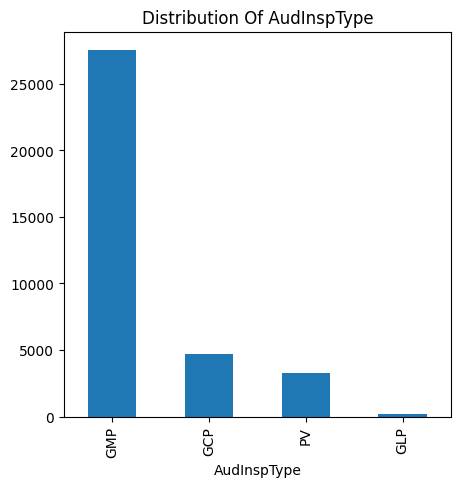

In [19]:
df["AudInspType"].value_counts().plot(kind='bar',title='Distribution Of AudInspType',figsize=(5,5))

<Axes: title={'center': 'Distribution Of AuditSubType'}, xlabel='AuditSubType'>

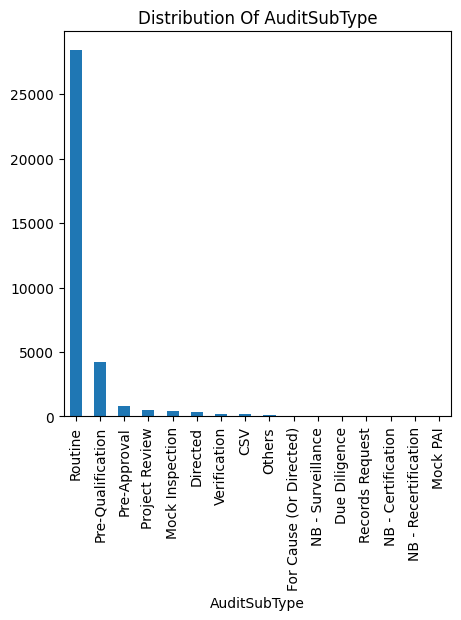

In [20]:
# AuditSubType
df["AuditSubType"].value_counts().plot(kind='bar',title='Distribution Of AuditSubType',figsize=(5,5))

<Axes: title={'center': 'Distribution Of Outcome'}, xlabel='Outcome'>

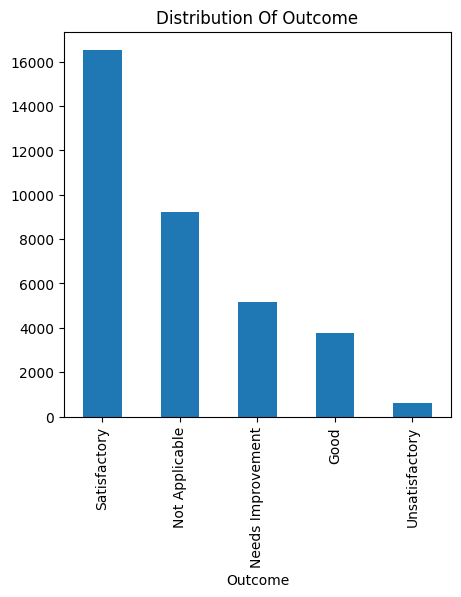

In [21]:
# Outcome
df["Outcome"].value_counts().plot(kind='bar',title='Distribution Of Outcome',figsize=(5,5))

<Axes: title={'center': 'Distribution Of ObservationRating'}, xlabel='ObservationRating'>

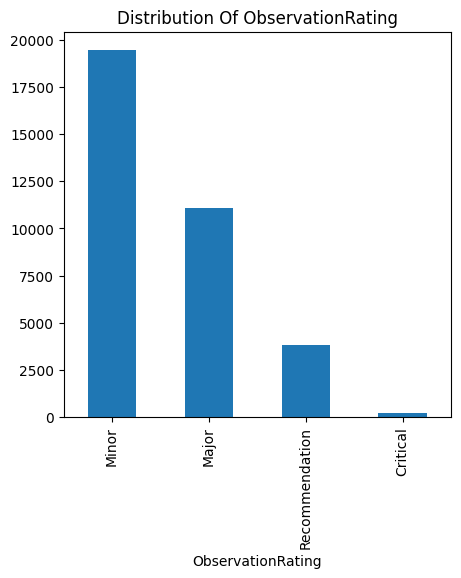

In [22]:
# ObservationRating
df["ObservationRating"].value_counts().plot(kind='bar',title='Distribution Of ObservationRating',figsize=(5,5))

<Axes: title={'center': 'Distribution Of DI_flag'}, xlabel='DI_flag'>

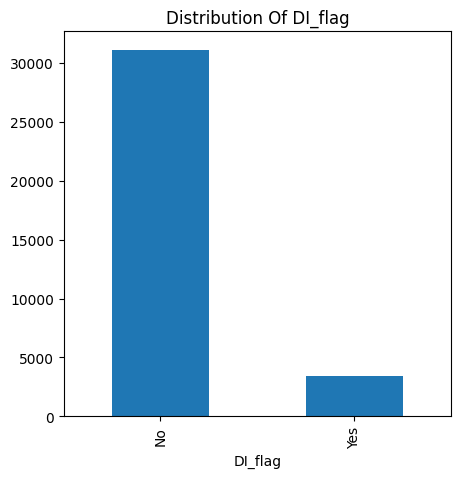

In [23]:
# DI_flag
df["DI_flag"].value_counts().plot(kind='bar',title='Distribution Of DI_flag',figsize=(5,5))

In [24]:
data = df[['DI_flag','ObsFullDescription']]

In [25]:
data.head(2)

,DI_flag,ObsFullDescription
0,No,Ensure that smoke studies are filmed in a mann...
1,No,Ensure that the release SOP require and descri...


In [26]:
data.isnull().sum()

DI_flag               1208
ObsFullDescription    1214
dtype: int64

In [27]:
data.shape

(35755, 2)

In [28]:
data.dropna(subset=['ObsFullDescription'],inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\3558572276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(subset=['ObsFullDescription'],inplace=True)


In [29]:
data.shape

(34541, 2)

In [30]:
data.isna().sum()

DI_flag               0
ObsFullDescription    0
dtype: int64

In [31]:
data["DI_flag"].value_counts()

DI_flag
No     31088
Yes     3453
Name: count, dtype: int64

<Axes: title={'center': 'Distribution Of DI_flag'}, xlabel='DI_flag'>

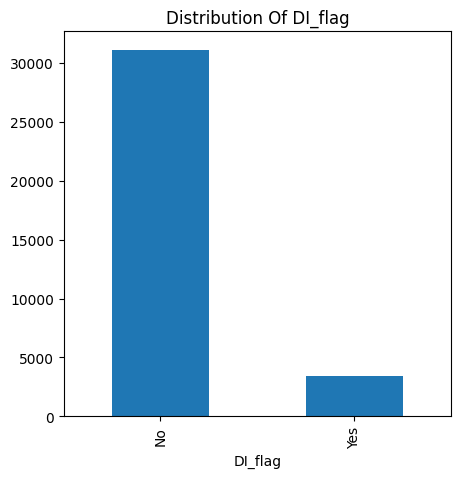

In [32]:
data["DI_flag"].value_counts().plot(kind='bar',title='Distribution Of DI_flag',figsize=(5,5))

In [33]:
data['DI_flag_Labels'] = data['DI_flag'].apply(lambda x : 1 if x == 'Yes' else 0)

C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\2003944054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['DI_flag_Labels'] = data['DI_flag'].apply(lambda x : 1 if x == 'Yes' else 0)


In [34]:
data.head(2)

,DI_flag,ObsFullDescription,DI_flag_Labels
0,No,Ensure that smoke studies are filmed in a mann...,0
1,No,Ensure that the release SOP require and descri...,0


In [35]:
data['DI_flag_Labels'].value_counts()

DI_flag_Labels
0    31088
1     3453
Name: count, dtype: int64

In [36]:
data.head(2)

,DI_flag,ObsFullDescription,DI_flag_Labels
0,No,Ensure that smoke studies are filmed in a mann...,0
1,No,Ensure that the release SOP require and descri...,0


In [37]:
data = data.drop(columns=['DI_flag'])

In [38]:
data.head(2)

,ObsFullDescription,DI_flag_Labels
0,Ensure that smoke studies are filmed in a mann...,0
1,Ensure that the release SOP require and descri...,0


In [39]:
# checking if there are any duplicate values in the dataset
data['ObsFullDescription'].nunique()

33313

In [40]:
#Removing duplicate entries
data1 = data.drop_duplicates(subset={"ObsFullDescription",'DI_flag_Labels'}, keep='first')

In [43]:
data1.shape

(33326, 2)

In [44]:
data1['ObsFullDescription'].nunique()

33313

In [45]:
data1.head(2)

,ObsFullDescription,DI_flag_Labels
0,Ensure that smoke studies are filmed in a mann...,0
1,Ensure that the release SOP require and descri...,0


In [46]:
import re
import nltk
from nltk.corpus import stopwords

In [47]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [49]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


True

In [50]:
STOPLIST = set(stopwords.words('english'))
len(STOPLIST)

198

In [53]:
STOPLIST = set(stopwords.words('english'))
remove_not = set(['not'])
STOPLIST_Upd = STOPLIST - remove_not
len(STOPLIST_Upd)

197

In [54]:
def preprocessing_description(data):
  preprocessed_events = []
  for sentence in data['ObsFullDescription'].values:
    sentence = re.sub(r'[^a-zA-Z]', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    sentence = ' '.join(e.lower() for e in sentence.split() if e.lower() not in STOPLIST_Upd)
    senetnce = ' '.join(e.lower() for e in sentence.split() if len(e) >= 2)
    preprocessed_events.append(sentence.strip())
  data['ObsFullDescription_cleaned'] = preprocessed_events
  return data

In [55]:
data_cleaned= preprocessing_description(data1)

C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\3470388419.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ObsFullDescription_cleaned'] = preprocessed_events


In [56]:
data_cleaned.head(2)

,ObsFullDescription,DI_flag_Labels,ObsFullDescription_cleaned
0,Ensure that smoke studies are filmed in a mann...,0,ensure smoke studies filmed manner appropriate...
1,Ensure that the release SOP require and descri...,0,ensure release sop require describe review non...


In [57]:
data_cleaned['ObsFullDescription_words_count'] = data_cleaned['ObsFullDescription'].str.strip().str.split(" ").str.len()
data_cleaned['ObsFullDescription_cleaned_count'] = data_cleaned['ObsFullDescription_cleaned'].str.strip().str.split(" ").str.len()

C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\3733490113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['ObsFullDescription_words_count'] = data_cleaned['ObsFullDescription'].str.strip().str.split(" ").str.len()
C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\3733490113.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['ObsFullDescription_cleaned_count'] = data_cleaned['ObsFullDescription_cleaned'].str.strip().str.split(" ").str.len()


In [58]:
from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()

def stem_words(text):
  return ' '.join([stemmer.stem(word) for word in text.split()])

data_cleaned['Obs_stemmed'] = data_cleaned.ObsFullDescription_cleaned.apply(lambda text: stem_words(text))

C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\1986014069.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Obs_stemmed'] = data_cleaned.ObsFullDescription_cleaned.apply(lambda text: stem_words(text))


In [59]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def text_lemmatize(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

data_cleaned['Obs_lemmatized'] = data_cleaned.ObsFullDescription_cleaned.apply(lambda text: text_lemmatize(text))

C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\2282336122.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Obs_lemmatized'] = data_cleaned.ObsFullDescription_cleaned.apply(lambda text: text_lemmatize(text))


In [60]:
data_cleaned.head(2)

,ObsFullDescription,DI_flag_Labels,ObsFullDescription_cleaned,ObsFullDescription_words_count,ObsFullDescription_cleaned_count,Obs_stemmed,Obs_lemmatized
0,Ensure that smoke studies are filmed in a mann...,0,ensure smoke studies filmed manner appropriate...,136,85,ensur smoke studi film manner appropri visual ...,ensure smoke study filmed manner appropriately...
1,Ensure that the release SOP require and descri...,0,ensure release sop require describe review non...,113,66,ensur releas sop requir describ review non con...,ensure release sop require describe review non...


In [61]:
data_cleaned['obs_stemmed_count'] = data_cleaned['Obs_stemmed'].str.strip().str.split(" ").str.len()

C:\Users\DELL\AppData\Local\Temp\ipykernel_23468\1835376442.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['obs_stemmed_count'] = data_cleaned['Obs_stemmed'].str.strip().str.split(" ").str.len()


In [62]:
data_cleaned.head()

,ObsFullDescription,DI_flag_Labels,ObsFullDescription_cleaned,ObsFullDescription_words_count,ObsFullDescription_cleaned_count,Obs_stemmed,Obs_lemmatized,obs_stemmed_count
0,Ensure that smoke studies are filmed in a mann...,0,ensure smoke studies filmed manner appropriate...,136,85,ensur smoke studi film manner appropri visual ...,ensure smoke study filmed manner appropriately...,85
1,Ensure that the release SOP require and descri...,0,ensure release sop require describe review non...,113,66,ensur releas sop requir describ review non con...,ensure release sop require describe review non...,66
2,Ensure the cleaning status of all mobile equip...,0,ensure cleaning status mobile equipment clearl...,48,29,ensur clean statu mobil equip clearli visibl m...,ensure cleaning status mobile equipment clearl...,29
3,Ensure that a justification provided in case a...,0,ensure justification provided case analytical ...,59,42,ensur justif provid case analyt method not val...,ensure justification provided case analytical ...,42
4,Ensure appropriate handling and qualification ...,0,ensure appropriate handling qualification stor...,140,76,ensur appropri handl qualif storag area approp...,ensure appropriate handling qualification stor...,76


In [63]:
x=data_cleaned['Obs_stemmed']
y=data_cleaned['DI_flag_Labels']

In [64]:
from sklearn.model_selection import train_test_split
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(x,y,random_state=0,test_size=.20)

In [65]:
X_train.shape

(26660,)

In [66]:
X_test.shape

(6666,)

In [67]:
y_train.shape

(26660,)

In [68]:
y_test.shape

(6666,)

In [69]:
from sklearn.feature_extraction.text import CountVectorizer
# Fit the CountVectorizer to the training data
vect_bow= CountVectorizer().fit(X_train)

In [70]:
vect_bow

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [72]:
len(vect_bow.get_feature_names_out())

42548

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Fit the CountVectorizer to the training data
vect_tfidf = TfidfVectorizer().fit(X_train)

In [74]:
len(vect_tfidf.get_feature_names_out())

42548

In [75]:
vect_bow.get_feature_names_out()[0:20]

array(['aa', 'aaa', 'aaaa', 'aaab', 'aaareg', 'aab', 'aad', 'aafc', 'aag',
       'aaipharma', 'aal', 'aalbert', 'aam', 'aamer', 'aamp', 'aan',
       'aanalyst', 'aanalyt', 'aanbevel', 'aanbevolen'], dtype=object)

In [76]:
vect_tfidf.get_feature_names_out()[0:20]

array(['aa', 'aaa', 'aaaa', 'aaab', 'aaareg', 'aab', 'aad', 'aafc', 'aag',
       'aaipharma', 'aal', 'aalbert', 'aam', 'aamer', 'aamp', 'aan',
       'aanalyst', 'aanalyt', 'aanbevel', 'aanbevolen'], dtype=object)

In [77]:
print("\nCreating the BOW vectors using the cleaned corpus")
X_train_bow = vect_bow.transform(X_train)
X_test_bow = vect_bow.transform(X_test)


Creating the BOW vectors using the cleaned corpus


In [78]:
print("\nCreating the TFIDF vectors using the cleaned corpus")
X_train_tfidf = vect_tfidf.transform(X_train)
X_test_tfidf = vect_tfidf.transform(X_test)


Creating the TFIDF vectors using the cleaned corpus


In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

In [80]:
def model_validation(X_train,y_train,X_test,y_test):
    try:
        validation_table_train=[]
        validation_table_test=[]
        #models=[LogisticRegression,KNeighborsClassifier,GaussianNB,DecisionTreeClassifier,RandomForestClassifier,BaggingClassifier]
        models=[DecisionTreeClassifier,RandomForestClassifier]
        for i in models:
            rd=i()
            rd.fit(X_train,y_train)
            #rd.predict(X_train)
            Train_Accuracy= accuracy_score(y_train, rd.predict(X_train))
            Confusion_Matrix= confusion_matrix(y_train, rd.predict(X_train))
            validation_table_train.append([i,Train_Accuracy,Confusion_Matrix])

            print("training completed for model: ", i)

            Test_Accuracy= accuracy_score(y_test, rd.predict(X_test))
            Confusion_Matrix_test= confusion_matrix(y_test, rd.predict(X_test))
            validation_table_test.append([i,Test_Accuracy,Confusion_Matrix_test])

        validation_table_train=pd.DataFrame(validation_table_train)
        validation_table_train.columns=["model name","Accuracy","confusion matrix"]

        validation_table_test=pd.DataFrame(validation_table_test)
        validation_table_test.columns=["model name","Accuracy","confusion matrix"]


        return validation_table_train,validation_table_test
    
    except Exception as e:
        print("model_validation function failed to run")
        print(e)

In [81]:
pd.options.display.float_format='{:0.2f}'.format

In [82]:
validation_table_train,validation_table_test = model_validation(X_train_bow,y_train,X_test_bow,y_test)

training completed for model:  <class 'sklearn.tree._classes.DecisionTreeClassifier'>
training completed for model:  <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [83]:
validation_table_train

,model name,Accuracy,confusion matrix
0,<class 'sklearn.tree._classes.DecisionTreeClas...,1.00,"[[23957, 3], [16, 2684]]"
1,<class 'sklearn.ensemble._forest.RandomForestC...,1.00,"[[23957, 3], [16, 2684]]"


In [84]:
validation_table_test

,model name,Accuracy,confusion matrix
0,<class 'sklearn.tree._classes.DecisionTreeClas...,0.89,"[[5669, 314], [397, 286]]"
1,<class 'sklearn.ensemble._forest.RandomForestC...,0.91,"[[5971, 12], [580, 103]]"


In [85]:
validation_table_train_tfidf,validation_table_test_tfidf = model_validation(X_train_tfidf,y_train,X_test_tfidf,y_test)

training completed for model:  <class 'sklearn.tree._classes.DecisionTreeClassifier'>
training completed for model:  <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [86]:
validation_table_train_tfidf

,model name,Accuracy,confusion matrix
0,<class 'sklearn.tree._classes.DecisionTreeClas...,1.00,"[[23957, 3], [16, 2684]]"
1,<class 'sklearn.ensemble._forest.RandomForestC...,1.00,"[[23957, 3], [16, 2684]]"


In [87]:
validation_table_test_tfidf

,model name,Accuracy,confusion matrix
0,<class 'sklearn.tree._classes.DecisionTreeClas...,0.89,"[[5643, 340], [381, 302]]"
1,<class 'sklearn.ensemble._forest.RandomForestC...,0.91,"[[5970, 13], [584, 99]]"


### Models are working well on training data but not working well on test data

In [88]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [89]:
y_pred = model_rf.predict(X_test_tfidf)
Train_Accuracy= accuracy_score(y_train, model_rf.predict(X_train_tfidf))
Test_Accuracy= accuracy_score(y_test, y_pred)
Confusion_Matrix_train= confusion_matrix(y_train, model_rf.predict(X_train_tfidf))
Confusion_Matrix_test= confusion_matrix(y_test, y_pred)

In [90]:
print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix_train)
print(Confusion_Matrix_test)

Train accuracy: 0.9992873218304577
Test accuracy: 0.9110411041104111
[[23955     5]
 [   14  2686]]
[[5973   10]
 [ 583  100]]


In [92]:
val = np.asmatrix(Confusion_Matrix_train) 
class_Labels = list(set(y_train))
df_cm_train = pd.DataFrame(val, index=class_Labels, columns=class_Labels)
print(df_cm_train)

       0     1
0  23955     5
1     14  2686


In [93]:
val_test = np.asmatrix(Confusion_Matrix_test) 
class_Labels = list(set(y_train))
df_cm_test = pd.DataFrame(val_test, index=class_Labels, columns=class_Labels)
print(df_cm_test)

      0    1
0  5973   10
1   583  100


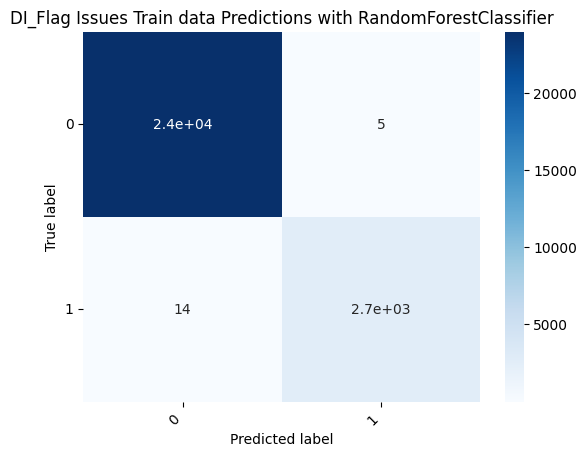

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
heatmap = sns.heatmap(df_cm_train, annot=True, cmap="Blues")
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('DI_Flag Issues Train data Predictions with RandomForestClassifier')
plt.show()

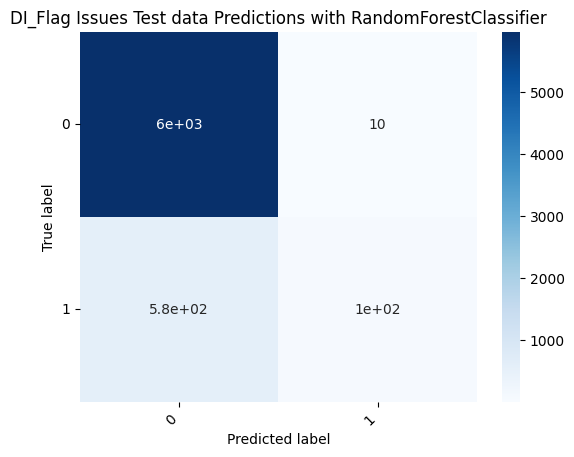

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
heatmap = sns.heatmap(df_cm_test, annot=True, cmap="Blues")
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('DI_Flag Issues Test data Predictions with RandomForestClassifier')
plt.show()

In [104]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 100, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt', 'log2']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2,4,6]
# Minimum number of samples required at each leaf node
min_samples_leaf = [2,4,6]
# Method of selecting samples for training each tree
bootstrap = [True, False]
criterion = ['gini', 'entropy']

# Create the parameters grid
param_grid = {'n_estimators': n_estimators,
              'criterion': criterion,
              'max_features': max_features,
              'max_depth': max_depth,
              'min_samples_split': min_samples_split,
              'min_samples_leaf': min_samples_leaf,
              'bootstrap': bootstrap}
print(param_grid)

{'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'criterion': ['gini', 'entropy'], 'max_features': ['auto', 'sqrt', 'log2'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 4, 6], 'min_samples_leaf': [2, 4, 6], 'bootstrap': [True, False]}


In [105]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier()
# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, 
                          cv = 3, n_jobs = -1, verbose = 2)

In [106]:
# Hyper Parameter tuning code took one and half day to provide the best parameters..  that's why commenting not to run again
'''
# Fit the grid search to the data
grid_search.fit(X_train_tfidf, y_train)
'''

'\n# Fit the grid search to the data\ngrid_search.fit(X_train_tfidf, y_train)\n'

In [107]:
#grid_search.best_params_

In [108]:
## Best parameters after running Grid SearchCV
'''
{'bootstrap': False,
 'criterion': 'gini',
 'max_depth': 90,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 10}
 '''

"\n{'bootstrap': False,\n 'criterion': 'gini',\n 'max_depth': 90,\n 'max_features': 'sqrt',\n 'min_samples_leaf': 2,\n 'min_samples_split': 2,\n 'n_estimators': 10}\n "

In [109]:
rf_tuned = RandomForestClassifier(n_estimators=10,criterion='gini',max_features='sqrt', max_depth=90,
                                 min_samples_split=2,min_samples_leaf=2,bootstrap=False,n_jobs=-1)

In [110]:
rf_tuned.fit(X_train_tfidf, y_train)
print("Train Accuracy:",rf_tuned.score(X_train_tfidf, y_train))
print("Test Accuracy:",rf_tuned.score(X_test_tfidf, y_test))

Train Accuracy: 0.9437734433608402
Test Accuracy: 0.9089408940894089


In [111]:
y_pred = rf_tuned.predict(X_test_tfidf)

Train_Accuracy= accuracy_score(y_train, rf_tuned.predict(X_train_tfidf))
Test_Accuracy= accuracy_score(y_test, y_pred)
Confusion_Matrix_train= confusion_matrix(y_train, rf_tuned.predict(X_train_tfidf))
Confusion_Matrix_test= confusion_matrix(y_test, y_pred)

print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix_train)
print(Confusion_Matrix_test)

Train accuracy: 0.9437734433608402
Test accuracy: 0.9089408940894089
[[23954     6]
 [ 1493  1207]]
[[5964   19]
 [ 588   95]]


In [112]:
import pickle

In [114]:
#save model to disk
filename = "Rf_tuned_DI_FLAG.sav"
pickle.dump(rf_tuned, open(filename, 'wb'))